**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**

---

# Sheet 7: Actionable Systems — Bayesian Decision Theory, Loss Functions & Predictive Checks
### *Closing the Loop from Posterior Distributions to Optimal Actions and Generative Validation*

Throughout Sheets 1 through 6, we mastered how to compute posterior distributions $p(\theta \mid D)$ across diverse modeling paradigms. However, an inference is not yet a decision: software systems, automated bots, and engineers must take discrete real-world actions.

In this capstone sheet, we formalize **Bayesian Decision Theory**: proving why the Posterior Mean, Median, and Mode (MAP) are optimal under $L_2$, $L_1$, and $0\text{-}1$ loss; deriving optimal asymmetric business cost cutoffs ($c^* = C_{\text{FP}} / (C_{\text{FP}} + C_{\text{FN}})$); and closing the workflow loop with **Prior and Posterior Predictive Checks (PPC)**.

---

---

## Table of Contents
1. **Part 1: The Formal Decision Framework**
   - Why Estimation is Only Half the Battle
   - States of Nature ($\Theta$), Action Space ($\mathcal{A}$), and Loss Matrices ($L(a, \theta)$)
   - Minimizing Posterior Expected Loss ($\mathbb{E}[L(a, \theta) \mid D]$)
2. **Part 2: Point Estimate Optimality Proofs ($L_2$, $L_1$, and $0\text{-}1$ Loss)**
   - Quadratic Loss ($L_2$) $\implies$ Posterior Mean
   - Linear / Absolute Loss ($L_1$) $\implies$ Posterior Median
   - $0\text{-}1$ Loss $\implies$ Posterior Mode (MAP)
   - Numerical Simulation & Loss Curve Minima
3. **Part 3: Asymmetric Engineering Loss — The Flaky Test Dilemma**
   - The Asymmetric Smoke Detector Metaphor
   - Cost of False Alarms ($C_{\text{FP}}$) vs. Cost of Missed Outages ($C_{\text{FN}}$)
   - Deriving the Optimal Decision Threshold $c^* = \frac{C_{\text{FP}}}{C_{\text{FP}} + C_{\text{FN}}}$
4. **Part 4: Generative Validation — Prior & Posterior Predictive Checks (PPC)**
   - The Generative Reality Mirror Metaphor
   - Simulating 2,000 Synthetic CI Test Suites
   - Discrepancy Test Statistics & Posterior Predictive $p$-values ($\text{ppp}$)
5. **Part 5: The Production Bayesian Decision Engine**
   - Automated Quarantine Engine under Economic Uncertainty
   - Testing Across Production Scenarios (Heathy, Borderline, Catastrophic)
6. **Part 6: Check Your Understanding (3-Tier Scaffolding Exercises)**
   - 🟢 Tier 1 (Warm-Up): Autonomous Drone Collision Cutoffs
   - 🟡 Tier 2 (Guided Calculation): Why Mean vs. Median Matters under Skewed Costs
   - 🔴 Tier 3 (Production Challenge): Diagnosing Extreme Predictive $p$-values

---
## Part 1: The Formal Decision Framework

In scientific research or production engineering, computing $p(\theta \mid D)$ is only half the battle. Eventually, a software system or decision-maker must **choose an action** $a \in \mathcal{A}$:
- *Should we deploy this release candidate or abort?*
- *Should we automatically quarantine this flaky test or let developers merge?*
- *Should we scale our cluster from 10 to 50 nodes?*

### The Elements of Bayesian Decision Theory (Wald, 1950)
1. **Parameter Space $\Theta$**: The true, unobservable state of nature (e.g., flakiness rate $\theta \in [0, 1]$).
2. **Action Space $\mathcal{A}$**: The set of possible choices available to the agent (e.g., $a_0 = \text{Pass}$, $a_1 = \text{Quarantine}$).
3. **Loss Function $L(a, \theta): \mathcal{A} \times \Theta \to \mathbb{R}$**: The quantifiable penalty or regret incurred by choosing action $a$ when the true state turns out to be $\theta$.
4. **Posterior Expected Loss $\rho(a, p)$**:
   $$\rho(a, p) = \mathbb{E}_{\theta \sim p(\theta \mid D)} [L(a, \theta)] = \int_\Theta L(a, \theta) \, p(\theta \mid D) \, d\theta$$

### The Bayes Decision Criterion
The **Bayes Optimal Action** $a^*$ is the action that minimizes expected loss under the posterior:
$$a^* = \arg\min_{a \in \mathcal{A}} \rho(a, p) = \arg\min_{a \in \mathcal{A}} \mathbb{E}[L(a, \theta) \mid D]$$

---
## Part 2: Point Estimate Optimality Proofs ($L_2$, $L_1$, and $0\text{-}1$ Loss)

Often in reporting, stakeholders demand a **single number** summary of $\theta$ (a point estimate $\hat{\theta} \in \Theta$). Which summary should you report: the **Mean**, **Median**, or **Mode (MAP)**?

Decision theory provides the mathematically rigorous answer: **the optimal point estimate is completely determined by your loss function.**

---

### Theorem 1: $L_2$ Squared Error Loss $\implies$ Posterior Mean
Let $L(a, \theta) = (a - \theta)^2$. The expected loss is:
$$\rho(a) = \int (a - \theta)^2 p(\theta \mid D) \, d\theta = a^2 - 2a \mathbb{E}[\theta \mid D] + \mathbb{E}[\theta^2 \mid D]$$
Differentiating with respect to $a$ and setting to zero:
$$\frac{d\rho}{da} = 2a - 2\mathbb{E}[\theta \mid D] = 0 \implies a^* = \mathbb{E}[\theta \mid D]$$
> **Result**: The **Posterior Mean** is the unique Bayes optimal point estimate if and only if errors penalize quadratically.

---

### Theorem 2: $L_1$ Absolute Error Loss $\implies$ Posterior Median
Let $L(a, \theta) = |a - \theta|$. The expected loss is:
$$\rho(a) = \int_{-\infty}^a (a - \theta) p(\theta \mid D) \, d\theta + \int_a^\infty (\theta - a) p(\theta \mid D) \, d\theta$$
Differentiating with respect to $a$ using Leibniz's rule:
$$\frac{d\rho}{da} = \int_{-\infty}^a p(\theta \mid D) \, d\theta - \int_a^\infty p(\theta \mid D) \, d\theta = 0$$
$$\implies P(\theta \le a^* \mid D) = P(\theta > a^* \mid D) = \frac{1}{2}$$
> **Result**: The **Posterior Median** is the unique Bayes optimal point estimate if and only if errors penalize linearly (robust to extreme outliers).

---

### Theorem 3: $0\text{-}1$ Loss $\implies$ Posterior Mode (MAP)
Let $L(a, \theta) = -\delta(a - \theta)$ (infinitesimal zero-loss tolerance around $\theta$).
$$\rho(a) = -p(a \mid D) \implies a^* = \arg\max_a p(a \mid D)$$
> **Result**: The **Posterior Mode (MAP)** is optimal only if you receive credit solely for an exact bullseye and penalize all near-misses equally.

--- Theoretical vs Empirical Minimizers ---


Theoretical Mean   (L2): 0.07407 | Empirical Minimum: 0.07428 


Theoretical Median (L1): 0.06372 | Empirical Minimum: 0.06346 


Theoretical Mode   (L0): 0.04 


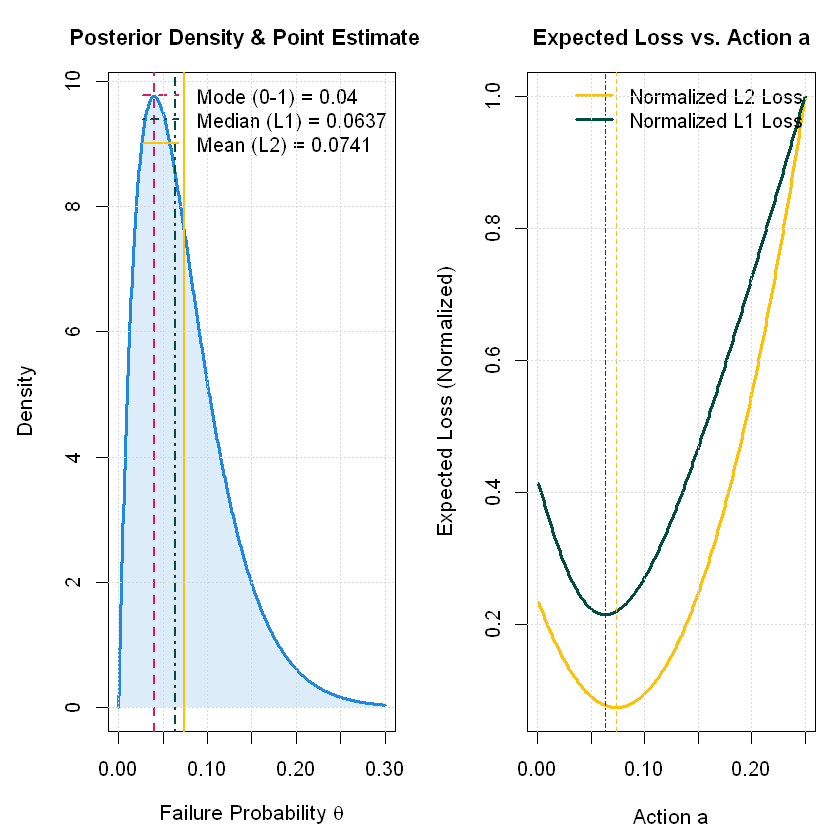

In [1]:
# Consider a skewed posterior for a rare failure rate: Beta(alpha=2, beta=25)
alpha_post <- 2
beta_post <- 25

# Theoretical point estimates
post_mean   <- alpha_post / (alpha_post + beta_post)
post_median <- qbeta(0.5, alpha_post, beta_post)
post_mode   <- (alpha_post - 1) / (alpha_post + beta_post - 2)

# Candidate actions across the domain
a_grid <- seq(0.001, 0.25, length.out = 300)

# Generate 100,000 posterior draws to compute empirical expected loss
set.seed(42)
posterior_samples <- rbeta(100000, alpha_post, beta_post)

# Compute expected loss curves
loss_squared  <- sapply(a_grid, function(a) mean((a - posterior_samples)^2))
loss_absolute <- sapply(a_grid, function(a) mean(abs(a - posterior_samples)))

# Minima of empirical curves
opt_squared  <- a_grid[which.min(loss_squared)]
opt_absolute <- a_grid[which.min(loss_absolute)]

# Visualization
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3, 1))

# Panel 1: Posterior density with point estimates
x <- seq(0, 0.3, length.out = 500)
plot(x, dbeta(x, alpha_post, beta_post), type = "l", col = "#1E88E5", lwd = 2.5,
     main = "Posterior Density & Point Estimates", xlab = expression(paste("Failure Probability ", theta)),
     ylab = "Density", cex.main = 1.1, cex.lab = 1.05)
polygon(c(x, rev(x)), c(dbeta(x, alpha_post, beta_post), rep(0, length(x))),
        col = rgb(30/255, 136/255, 229/255, 0.15), border = NA)
abline(v = post_mode, col = "#D81B60", lwd = 2, lty = 2)
abline(v = post_median, col = "#004D40", lwd = 2, lty = 4)
abline(v = post_mean, col = "#FFC107", lwd = 2, lty = 1)
legend("topright", legend = c(paste0("Mode (0-1) = ", round(post_mode, 4)),
                              paste0("Median (L1) = ", round(post_median, 4)),
                              paste0("Mean (L2) = ", round(post_mean, 4))),
       col = c("#D81B60", "#004D40", "#FFC107"), lty = c(2, 4, 1), lwd = 2, bty = "n")
grid(col = "gray85")

# Panel 2: Expected loss curves
plot(a_grid, loss_squared / max(loss_squared), type = "l", col = "#FFC107", lwd = 2.5,
     main = "Expected Loss vs. Action a", xlab = "Action a", ylab = "Expected Loss (Normalized)",
     cex.main = 1.1, cex.lab = 1.05)
lines(a_grid, loss_absolute / max(loss_absolute), col = "#004D40", lwd = 2.5)
abline(v = post_mean, col = "#FFC107", lty = 2, lwd = 1.5)
abline(v = post_median, col = "#004D40", lty = 4, lwd = 1.5)
legend("topright", legend = c("Normalized L2 Loss", "Normalized L1 Loss"),
       col = c("#FFC107", "#004D40"), lwd = 2.5, bty = "n")
grid(col = "gray85")

cat("--- Theoretical vs Empirical Minimizers ---\n")
cat("Theoretical Mean   (L2):", round(post_mean, 5), "| Empirical Minimum:", round(opt_squared, 5), "\n")
cat("Theoretical Median (L1):", round(post_median, 5), "| Empirical Minimum:", round(opt_absolute, 5), "\n")
cat("Theoretical Mode   (L0):", round(post_mode, 5), "\n")

---
## Part 3: Asymmetric Engineering Loss — The Flaky Test Dilemma

In real-world engineering, symmetric losses ($L_1, L_2$) are rarely appropriate. Costs are drastically asymmetric:



### The Asymmetric Smoke Detector: Why 50% is Lethal

Why does a household smoke detector beep when you burn a piece of toast?
Because the underlying cost matrix is profoundly asymmetric:
- **Cost of False Positive (Burnt Toast)**: $\approx \$0$ (waving a dishtowel for 30 seconds; a minor annoyance).
- **Cost of False Negative (House Fire)**: $\infty$ (catastrophic destruction of property and loss of human life).

A smoke detector engineered with a "symmetric" $50\%$ probability threshold would kill millions of people! Because a missed fire is infinitely worse than a false alarm, the Bayes-optimal decision rule demands triggering the alarm when fire probability is merely $0.1\%$.

```text
       SYMMETRIC LOSS (Textbook Myth)                 ASYMMETRIC REALITY (Production Systems)
   Cost                                           Cost
    ▲                                              ▲
    │         False Alarm = Missed Fire            │                 Missed Fire ($10,000)
    │                  ($100)                      │                           ▲
    │                    ▲                         │                           │
    │                    │                         │    False Alarm ($150)     │
    │                    │                         │            ▲              │
    └────────────────────┴───────────►             └────────────┼──────────────┴──────────►
                       Error                                  FP             FN
```

In software engineering, CI/CD test quarantine operates under the identical asymmetric math:
- **Action $a_0$ (Pass Test)**: If the test was actually flaky, a broken commit merges into `main`, breaking the build for $50$ engineers and costing thousands of dollars in lost velocity ($C_{\text{FN}} = \$2,000$).
- **Action $a_1$ (Quarantine Test)**: If the test was actually healthy, a developer spends $1$ hour investigating a false alarm ($C_{\text{FP}} = \$150$).

### The Production Scenario
Suppose a test in your automated CI pipeline has an unobserved failure probability $\theta$.
- **Definition of "Flaky"**: A test is considered unacceptably flaky if $\theta > \theta_{\text{crit}} = 0.05$ (5% failure rate).
- **Available Actions**:
  - $a_0$: **Pass / Do Nothing** (Keep test active in CI).
  - $a_1$: **Quarantine** (Remove test from the merge-blocking path and alert on-call).

### The Cost Matrix
| True State | Action $a_0$ (Pass) | Action $a_1$ (Quarantine) |
| :--- | :--- | :--- |
| **Healthy** ($\theta \le 0.05$) | **$0** (All clear) | **$C_{\text{triage}} = \$150** (Wasted engineering time to investigate) |
| **Flaky** ($\theta > 0.05$) | **$C_{\text{incident}} = \$5,000** (Broken builds, delayed merges, release rollbacks) | **$C_{\text{triage}} = \$150** (Triage cost to fix test) |

---

### Derivation of the Optimal Decision Threshold $c^*$
Let $p_{\text{flaky}} = P(\theta > 0.05 \mid D)$ be the posterior probability that the test is flaky.

1. **Expected Loss of Action $a_1$ (Quarantine)**:
   $$\mathbb{E}[L(a_1)] = C_{\text{triage}} = \$150$$

2. **Expected Loss of Action $a_0$ (Pass)**:
   $$\mathbb{E}[L(a_0)] = p_{\text{flaky}} \cdot C_{\text{incident}} + (1 - p_{\text{flaky}}) \cdot 0 = p_{\text{flaky}} \cdot \$5,000$$

3. **Optimal Decision Rule**:
   Quarantine if and only if $\mathbb{E}[L(a_1)] < \mathbb{E}[L(a_0)]$:
   $$C_{\text{triage}} < p_{\text{flaky}} \cdot C_{\text{incident}} \implies p_{\text{flaky}} > \frac{C_{\text{triage}}}{C_{\text{incident}}} = \frac{150}{5000} = 0.03$$

> 💡 **The Core Lesson**: You should quarantine when there is only a **3% probability** that the test is flaky! 
> A naive engineer waiting for a $50\%$ majority vote or a $95\%$ confidence interval would incur massive financial losses.

Optimal Quarantine Threshold: P(flaky) > 3 %


At P(flaky) = 10%: Cost of Pass = $ 500 vs Quarantine = $ 150 


Net savings per test decision: 350 


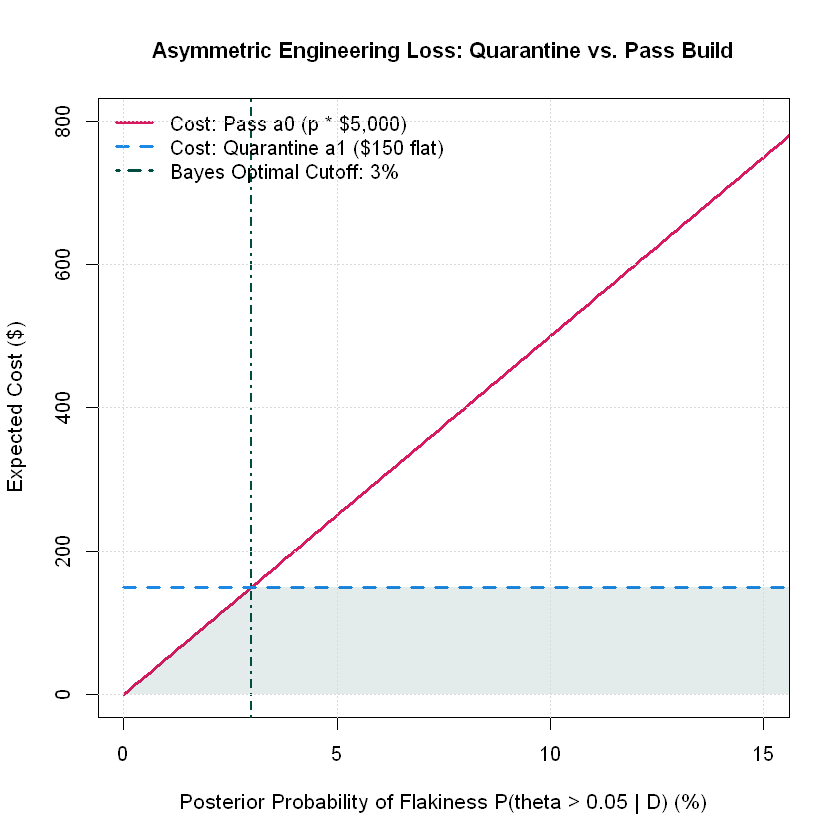

In [2]:
# Economic parameters
C_triage <- 150        # Cost of developer investigating ($)
C_incident <- 5000     # Cost of flaky test disrupting builds ($)
optimal_threshold <- C_triage / C_incident  # 0.03

# Probability grid of p_flaky
p_grid <- seq(0, 0.20, length.out = 200)

# Expected loss functions ($)
loss_pass <- p_grid * C_incident
loss_quarantine <- rep(C_triage, length(p_grid))

# Visualization
plot(p_grid * 100, loss_pass, type = "l", col = "#D81B60", lwd = 2.5,
     main = "Asymmetric Engineering Loss: Quarantine vs. Pass Build",
     xlab = "Posterior Probability of Flakiness P(theta > 0.05 | D) (%)",
     ylab = "Expected Cost ($)", xlim = c(0, 15), ylim = c(0, 800),
     cex.main = 1.1, cex.lab = 1.05)
lines(p_grid * 100, loss_quarantine, col = "#1E88E5", lwd = 2.5, lty = 2)
abline(v = optimal_threshold * 100, col = "#004D40", lwd = 2, lty = 4)

polygon(c(p_grid * 100, rev(p_grid * 100)),
        c(pmin(loss_pass, loss_quarantine), rep(0, length(p_grid))),
        col = rgb(0/255, 77/255, 64/255, 0.1), border = NA)

legend("topleft", legend = c("Cost: Pass a0 (p * $5,000)", "Cost: Quarantine a1 ($150 flat)",
                             paste0("Bayes Optimal Cutoff: ", round(optimal_threshold * 100, 1), "%")),
       col = c("#D81B60", "#1E88E5", "#004D40"), lty = c(1, 2, 4), lwd = 2.5, bty = "n")
grid(col = "gray85")

cat("Optimal Quarantine Threshold: P(flaky) >", round(optimal_threshold * 100, 1), "%\n")
cat("At P(flaky) = 10%: Cost of Pass = $", 0.10 * C_incident, "vs Quarantine = $", C_triage, "\n")
cat("Net savings per test decision:", 0.10 * C_incident - C_triage, "\n")

---
## Part 4: Generative Validation — Prior & Posterior Predictive Checks

A model can compute an exact mathematical posterior, yet still be catastrophically wrong about the physical world. 
**Predictive Checks** test whether your model can simulate realistic data.

```
          ┌────────────────────────────────────────────────────────┐
          │               THE BAYESIAN GENERATIVE LOOP             │
          │                                                        │
          │  1. Priors p(θ) ───────────► Prior Predictive Check    │
          │        │                            │                  │
          │        ▼                            ▼                  │
          │  2. Data (D)  ─────────────► Posterior p(θ|D)          │
          │                                     │                  │
          │                                     ▼                  │
          │  3. Replications y^rep ────► Posterior Predictive Check│
          └────────────────────────────────────────────────────────┘
```

---

### 1. Prior Predictive Checks (Sanity Checking Your Assumptions)
Before collecting any data, draw parameter values from your prior, and simulate synthetic datasets:
$$\theta^{(s)} \sim p(\theta), \quad y^{(s)} \sim p(y \mid \theta^{(s)})$$
If your prior allows 500% failure rates or negative response times, your prior is encoding impossible physics and must be regularized.

---

### 2. Posterior Predictive Checks (Model Adequacy)
After computing $p(\theta \mid D)$, generate $S$ replicated datasets $y^{\text{rep}}$ of the exact same size as the observed data $y^{\text{obs}}$:
$$\theta^{(s)} \sim p(\theta \mid D), \quad y^{\text{rep},(s)} \sim p(y \mid \theta^{(s)})$$
Then choose a **test statistic** $T(y)$ that captures an aspect of the data you care about (e.g., maximum streak of consecutive failures, variance-to-mean ratio).

#### The Bayesian Posterior Predictive p-value (ppp)
$$\text{ppp} = P(T(y^{\text{rep}}) \ge T(y^{\text{obs}}) \mid D) = \frac{1}{S} \sum_{s=1}^S \mathbf{1}_{\{T(y^{\text{rep},(s)}) \ge T(y^{\text{obs}})\}}$$
- **$\text{ppp} \approx 0.50$**: The model reproduces this feature of reality with perfect balance.
- **$\text{ppp} < 0.02$ or $\text{ppp} > 0.98$**: The model is misspecified for this feature (e.g., failing to model clustering or temporal dependence).

### The Generative Reality Mirror: Can Your Model Hallucinate Real Data?

A model can output razor-thin credible intervals ($95\%\text{ CI}: [0.038, 0.042]$) and still be completely delusional about physical reality.

How do we catch a confident, broken model? We hold up a **Generative Reality Mirror**:
1. We ask the model: *"If your posterior beliefs are true, simulate $2,000$ synthetic test suites for next week."*
2. We compute a summary discrepancy statistic on the synthetic datasets—such as the **maximum streak of consecutive failures**—and compare it against the real historical CI log.
3. If the model's simulated universes produce max streaks of $2$ failures, but real CI logs routinely see bursts of $8$ consecutive network timeouts, **the model is broken**. Its binomial independence assumption has failed.

> [!IMPORTANT]
> **The Golden Rule of Generative Modeling**: If your model cannot generate synthetic data that looks indistinguishable from real data, its parameter estimates and credible intervals cannot be trusted for real decisions!

Posterior Predictive Check Summary:


- Observed Failures: 6 | Mean Replicated: 6.9155 | ppp: 0.619 


- Observed Streak:   1 | Mean Replicated: 1.3935 | ppp: 0.994 


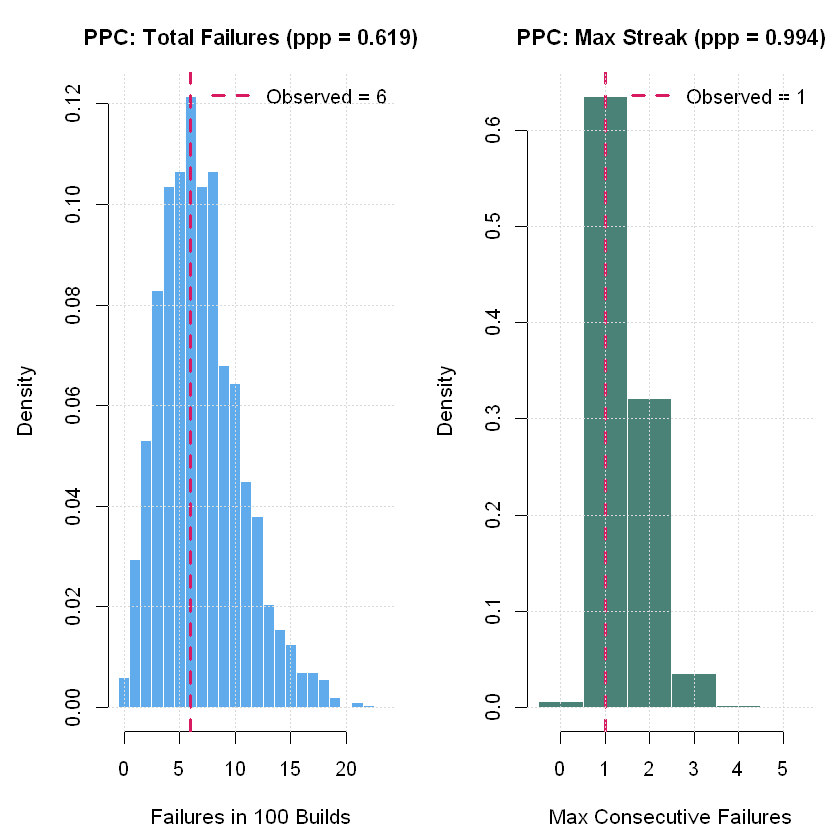

In [3]:
# Step 1: Observed CI test suite data (100 builds, 6 failures observed)
n_builds <- 100
k_failures_obs <- 6
set.seed(42)
y_obs <- sample(c(rep(1, k_failures_obs), rep(0, n_builds - k_failures_obs)))

# Metric of interest: Maximum streak of consecutive failures
max_streak <- function(binary_vec) {
  runs <- rle(binary_vec)
  streak_1s <- runs$lengths[runs$values == 1]
  if (length(streak_1s) == 0) return(0)
  max(streak_1s)
}

t_obs_streak <- max_streak(y_obs)

# Step 2: Posterior distribution: Beta(1 + 6, 1 + 94) = Beta(7, 95)
a_prior <- 1; b_prior <- 1
a_post <- a_prior + k_failures_obs
b_post <- b_prior + (n_builds - k_failures_obs)

# Step 3: Draw 2,000 replicated datasets from the posterior predictive distribution
S <- 2000
set.seed(123)
theta_draws <- rbeta(S, a_post, b_post)

y_rep_failures <- numeric(S)
y_rep_streaks  <- numeric(S)

for (s in 1:S) {
  y_rep <- rbinom(n_builds, size = 1, prob = theta_draws[s])
  y_rep_failures[s] <- sum(y_rep)
  y_rep_streaks[s]  <- max_streak(y_rep)
}

# Step 4: Compute posterior predictive p-values
ppp_failures <- mean(y_rep_failures >= k_failures_obs)
ppp_streaks  <- mean(y_rep_streaks >= t_obs_streak)

# Visualization
par(mfrow = c(1, 2), mar = c(4.5, 4.5, 3, 1))

# Panel 1: Replicated total failures vs Observed
max_f <- max(y_rep_failures)
hist(y_rep_failures, breaks = seq(-0.5, max_f + 1.5, by = 1), prob = TRUE, col = rgb(30/255, 136/255, 229/255, 0.7),
     border = "white", main = paste0("PPC: Total Failures (ppp = ", round(ppp_failures, 3), ")"),
     xlab = "Failures in 100 Builds", cex.main = 1.1, cex.lab = 1.05)
abline(v = k_failures_obs, col = "#D81B60", lwd = 2.5, lty = 2)
legend("topright", legend = paste0("Observed = ", k_failures_obs), col = "#D81B60", lty = 2, lwd = 2.5, bty = "n")
grid(col = "gray85")

# Panel 2: Replicated max streak vs Observed
hist(y_rep_streaks, breaks = seq(-0.5, max(y_rep_streaks) + 1.5, by = 1), prob = TRUE,
     col = rgb(0/255, 77/255, 64/255, 0.7), border = "white",
     main = paste0("PPC: Max Streak (ppp = ", round(ppp_streaks, 3), ")"),
     xlab = "Max Consecutive Failures", cex.main = 1.1, cex.lab = 1.05)
abline(v = t_obs_streak, col = "#D81B60", lwd = 2.5, lty = 2)
legend("topright", legend = paste0("Observed = ", t_obs_streak), col = "#D81B60", lty = 2, lwd = 2.5, bty = "n")
grid(col = "gray85")

cat("Posterior Predictive Check Summary:\n")
cat("- Observed Failures:", k_failures_obs, "| Mean Replicated:", mean(y_rep_failures), "| ppp:", round(ppp_failures, 3), "\n")
cat("- Observed Streak:  ", t_obs_streak, "| Mean Replicated:", mean(y_rep_streaks), "| ppp:", round(ppp_streaks, 3), "\n")

---
## Part 5: The Production Bayesian Decision Engine

Below is a production-grade automated quarantine engine combining:
1. **Conjugate Beta updating** on real-time CI test runs.
2. **Asymmetric economic loss evaluation** over candidate actions ($a_0 = \text{Pass}, a_1 = \text{Quarantine}$).
3. **Automated policy decision** with financial risk audit logging.

In [4]:
evaluate_test_quarantine_policy <- function(k_failures, n_runs,
                                            c_triage = 150.0,
                                            c_incident = 5000.0,
                                            flaky_threshold = 0.05,
                                            prior_a = 1.0, prior_b = 1.0) {
  # Posterior Beta parameters
  a_post <- prior_a + k_failures
  b_post <- prior_b + (n_runs - k_failures)
  
  # Probability of being flaky P(theta > flaky_threshold)
  p_flaky <- 1 - pbeta(flaky_threshold, a_post, b_post)
  
  # Expected loss for candidate actions
  loss_pass <- p_flaky * c_incident
  loss_quarantine <- c_triage
  
  # Optimal action and threshold
  optimal_cutoff <- c_triage / c_incident
  action <- ifelse(p_flaky > optimal_cutoff, "QUARANTINE", "PASS")
  savings <- abs(loss_pass - loss_quarantine)
  
  list(
    runs = n_runs,
    failures = k_failures,
    post_mean_theta = a_post / (a_post + b_post),
    p_flaky = p_flaky,
    optimal_cutoff = optimal_cutoff,
    expected_cost_pass = loss_pass,
    expected_cost_quarantine = loss_quarantine,
    recommended_action = action,
    net_expected_savings = savings
  )
}

# Test across 3 production scenarios
scenarios <- list(
  list(name = "Stable Test", k = 0, n = 80),
  list(name = "Suspicious Early Warning", k = 3, n = 50),
  list(name = "Confirmed Toxic Flake", k = 9, n = 100)
)

cat(sprintf("%-25s | %-5s | %-8s | %-10s | %-11s | %s\n",
            "Scenario", "Runs", "Failures", "P(Flaky)", "Action", "Expected Risk"))
cat(paste(rep("-", 80), collapse = ""), "\n")

for (sc in scenarios) {
  res <- evaluate_test_quarantine_policy(sc$k, sc$n)
  chosen_cost <- ifelse(res$recommended_action == "QUARANTINE", res$expected_cost_quarantine, res$expected_cost_pass)
  cat(sprintf("%-25s | %-5d | %-8d | %7.2f%%  | %-11s | $%7.2f\n",
              sc$name, res$runs, res$failures, res$p_flaky * 100, res$recommended_action, chosen_cost))
}

Scenario                  | Runs  | Failures | P(Flaky)   | Action      | Expected Risk


-------------------------------------------------------------------------------- 


Stable Test               | 80    | 0        |    1.57%  | PASS        | $  78.45
Suspicious Early Warning  | 50    | 3        |   74.94%  | QUARANTINE  | $ 150.00
Confirmed Toxic Flake     | 100   | 9        |   97.01%  | QUARANTINE  | $ 150.00


## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): Asymmetric Decision Cutoffs in Safety Systems
> **Scenario**: An autonomous drone collision prevention system has two actions: $a_0 = \text{Maintain Course}$ and $a_1 = \text{Emergency Brake}$. 
> If it brakes unnecessarily (False Positive), it costs $\$10$ in lost battery efficiency. If it fails to brake when an obstacle exists (False Negative), the crash costs $\$10,000$.
> What is the Bayes optimal collision probability threshold $c^*$ at which the drone must hit the brakes?

In [ ]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
cost_false_positive <- 10.0     # cost of unnecessary braking
cost_false_negative <- 10000.0  # cost of crash if obstacle exists

# Bayes optimal threshold:
# Brake if E[L(brake)] < E[L(maintain)]
# c_star <- ...

# cat(sprintf("Optimal Collision Threshold: %.4f%%\n", c_star * 100))


<details>
<summary><b>🔍 Click here to view the solution & mathematical derivation</b></summary>

**Answer**: $c^* = 0.1\%$ (or $p > 0.001$).

**Derivation**:
$$\mathbb{E}[L(a_1)] = \$10$$
$$\mathbb{E}[L(a_0)] = p \cdot \$10,000$$
Brake if:
$$\mathbb{E}[L(a_1)] < \mathbb{E}[L(a_0)] \implies \$10 < p \cdot \$10,000 \implies p > \frac{10}{10000} = 0.001 = 0.1\%$$
Waiting until you are even $1\%$ or $5\%$ confident of a collision would be catastrophic negligence.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Why Mean vs. Median Matters in Production SLAs
> **Scenario**: A database query latency posterior is log-normal with a heavy right tail:
> - Posterior Median = $15\text{ ms}$
> - Posterior Mean = $85\text{ ms}$
> - Posterior Mode (MAP) = $8\text{ ms}$
>
> If your client SLA contract penalizes you linearly for the absolute error of your latency forecast ($L_1 = |a - \theta|$), which point estimate should you commit to in the SLA to minimize expected penalties?

In [ ]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
median_latency <- 15.0
mean_latency <- 85.0
mode_latency <- 8.0

# Under L1 loss L(a, theta) = |a - theta|:
# Which estimate is the Bayes optimal point prediction?
optimal_prediction <- NA  # median_latency, mean_latency, or mode_latency

# Write your rationale below:


<details>
<summary><b>🔍 Click here to view the solution & optimality proof</b></summary>

**Answer**: Commit to the **Median ($15\text{ ms}$)**.

**Derivation**:
By Theorem 2, the Bayes optimal point estimate for $L_1$ absolute error loss $L(a, \theta) = |a - \theta|$ is strictly the **Posterior Median**. 
Reporting the Mean ($85\text{ ms}$) would minimize squared penalties ($L_2$), which over-penalizes rare extreme tail spikes and artificially inflates your linear SLA forecast error. Reporting the Mode ($8\text{ ms}$) would maximize point-density ($0\text{-}1$ loss), which ignores the magnitude of all misses.
</details>

---

### 🔴 Tier 3 (Production Challenge): Interpreting Extreme Posterior Predictive p-values
> **Scenario**: You run a posterior predictive check on 1,000 simulated test suites generated from your posterior $p(\theta \mid D)$. 
> You choose the discrepancy statistic $T(y) = \text{Maximum Consecutive Failure Streak}$.
> - Observed data streak: $T(y^{\text{obs}}) = 5\text{ consecutive failures}$.
> - Across all 1,000 replicated datasets, $T(y^{\text{rep}})$ never exceeds $2$ (yielding an empirical $\text{ppp} = 0.000$).
>
> 1. What does this diagnose about your standard independent Bernoulli/Binomial model?
> 2. What underlying physical phenomenon in software engineering causes this failure?
> 3. What model architecture resolves it?

In [ ]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
t_obs <- 5  # observed failure streak
t_rep_max <- 2  # max streak across all 1,000 posterior replications

# ppp = mean(t_rep >= t_obs) = 0.000
# 1. What does ppp = 0.000 diagnose about an independent Binomial model?
# 2. What real-world phenomenon causes clustered failures in software tests?
# 3. What Bayesian model architectures handle overdispersion / temporal clustering?


<details>
<summary><b>🔍 Click here to view the model diagnostic & resolution</b></summary>

**Diagnosis & Resolution**:
1. **Model Failure (Overdispersion & Clustering)**: A $\text{ppp} = 0.000$ indicates that the observed failure streak of 5 is virtually impossible under the fitted independent Binomial model. The model is severely misspecified for temporal clustering.
2. **Physical Phenomenon**: In software engineering, test failures are rarely independent coin flips. A bad merge, broken Docker dependency, or external database outage causes **failure bursts** where consecutive runs fail together until a fix is deployed.
3. **Model Resolution**: 
   - Upgrade from standard Binomial to a **Beta-Binomial mixture model** (which models overdispersion).
   - Use a **Dynamic State-Space Model with Memory Decay** (Sheet 6) to model time-varying failure states.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**